<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/02_AngioCAD_%EC%A0%84%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 데이터 및 감사 결과 복구
2. Clinical cleaning rule 재적용
3. 이미지 pixel hash 중복 검사

In [33]:
from google.colab import drive

drive.mount("/content/drive")

!apt-get update -qq
!apt-get install -y -qq unrar

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
#@title 프로젝트 경로 자동 탐색

from pathlib import Path
import pandas as pd
import numpy as np

DRIVE_ROOT = Path("/content/drive/MyDrive")

part1_candidates = list(
    DRIVE_ROOT.rglob(
        "AngioCAD_Dataset.part1.rar"
    )
)

if len(part1_candidates) != 1:
    raise RuntimeError(
        f"part1.rar 검색 결과: "
        f"{len(part1_candidates)}개"
    )

PROJECT_DIR = part1_candidates[0].parent
AUDIT_DIR = PROJECT_DIR / "audit_results"
PREPROCESS_DIR = PROJECT_DIR / "preprocessing_results"
SPLIT_DIR = PROJECT_DIR / "splits"

PREPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EXTRACT_ROOT = Path("/content/AngioCAD")
DATASET_DIR = (
    EXTRACT_ROOT / "AngioCAD_Dataset"
)

FEATURES_FILE = (
    PROJECT_DIR / "AngioCAD_Features.xlsx"
)

print("프로젝트:", PROJECT_DIR)
print("Audit:", AUDIT_DIR)
print("전처리 결과:", PREPROCESS_DIR)
print("Split:", SPLIT_DIR)

프로젝트: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
Audit: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results
전처리 결과: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results
Split: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/splits


In [ ]:
#@title 필수 감사 결과 존재 여부

REQUIRED_AUDIT_FILES = [
    "13_series_view_manifest.csv",
    "14_paper_model_series.csv",
    "15_extended_model_series.csv",
    "19_patient_label_summary.csv",
    "20_paper_series_with_labels.csv",
    "21_extended_series_with_labels.csv",
    "28_patient_modality_eligibility.csv",
    "36_clinical_cleaning_rules.csv",
    "37_clinical_cleaned_preview.csv",
]

missing_audit_files = [
    file_name
    for file_name in REQUIRED_AUDIT_FILES
    if not (
        AUDIT_DIR / file_name
    ).exists()
]

if missing_audit_files:
    raise FileNotFoundError(
        "필수 감사 결과 누락:\n"
        + "\n".join(missing_audit_files)
    )

print("✅ 필수 감사 결과가 모두 존재합니다.")

✅ 필수 감사 결과가 모두 존재합니다.


In [ ]:
#@title rar 재압축 해제
# 분할 압축 및 디스크 공간 확인

import shutil

rar_parts = [
    PROJECT_DIR
    / f"AngioCAD_Dataset.part{i}.rar"
    for i in range(1, 5)
]

for path in rar_parts:
    print(
        path.name,
        "존재:",
        path.exists(),
        "크기:",
        (
            f"{path.stat().st_size / 1024**3:.2f} GiB"
            if path.exists()
            else "-"
        ),
    )

assert all(
    path.exists()
    for path in rar_parts
), "분할압축 파일이 누락됐습니다."

total, used, free = shutil.disk_usage(
    "/content"
)

print(
    f"\n남은 로컬 공간: "
    f"{free / 1024**3:.1f} GiB"
)

if free < 25 * 1024**3:
    raise RuntimeError(
        "로컬 여유 공간이 25GiB 미만입니다."
    )


AngioCAD_Dataset.part1.rar 존재: True 크기: 3.91 GiB
AngioCAD_Dataset.part2.rar 존재: True 크기: 3.91 GiB
AngioCAD_Dataset.part3.rar 존재: True 크기: 3.91 GiB
AngioCAD_Dataset.part4.rar 존재: True 크기: 3.56 GiB

남은 로컬 공간: 205.5 GiB


In [ ]:
#@title 필요한 경우에만 압축 해제

import subprocess
import time

if DATASET_DIR.exists():
    existing_patients = [
        path
        for path in DATASET_DIR.iterdir()
        if path.is_dir()
        and path.name.isdigit()
    ]
else:
    existing_patients = []

if len(existing_patients) == 413:
    print(
        "기존 압축 해제본을 재사용합니다."
    )
else:
    EXTRACT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    start_time = time.time()

    command = [
        "unrar",
        "x",
        "-o+",
        "-idq",
        str(rar_parts[0]),
        str(EXTRACT_ROOT) + "/",
    ]

    print("압축 해제를 시작합니다.")

    result = subprocess.run(command)

    if result.returncode != 0:
        raise RuntimeError(
            f"압축 해제 실패: "
            f"code={result.returncode}"
        )

    print(
        f"압축 해제 완료: "
        f"{(time.time()-start_time)/60:.1f}분"
    )

압축 해제를 시작합니다.
압축 해제 완료: 6.5분


In [ ]:
#@title 압축해제 결과 재검증

patient_dirs = sorted(
    [
        path
        for path in DATASET_DIR.iterdir()
        if path.is_dir()
        and path.name.isdigit()
    ],
    key=lambda path: int(path.name),
)

series_dirs = [
    series_dir
    for patient_dir in patient_dirs
    for series_dir in patient_dir.iterdir()
    if series_dir.is_dir()
    and series_dir.name.isdigit()
]

all_png_paths = [
    png_path
    for series_dir in series_dirs
    for png_path in series_dir.glob("*.png")
]

print("환자 폴더:", len(patient_dirs))
print("Series:", len(series_dirs))
print("PNG:", len(all_png_paths))

assert len(patient_dirs) == 413
assert len(series_dirs) == 2711
assert len(all_png_paths) == 121566

print("✅ 압축 해제본이 원본 감사 결과와 일치합니다.")

환자 폴더: 413
Series: 2711
PNG: 121566
✅ 압축 해제본이 원본 감사 결과와 일치합니다.


In [ ]:
#@title 저장되노 mainifest 복구
#모델 cohort 및 target 복구

series_view_manifest_df = pd.read_csv(
    AUDIT_DIR
    / "13_series_view_manifest.csv"
)

paper_model_series_df = pd.read_csv(
    AUDIT_DIR
    / "14_paper_model_series.csv"
)

extended_model_series_df = pd.read_csv(
    AUDIT_DIR
    / "15_extended_model_series.csv"
)

patient_label_summary_df = pd.read_csv(
    AUDIT_DIR
    / "19_patient_label_summary.csv"
)

paper_series_label_df = pd.read_csv(
    AUDIT_DIR
    / "20_paper_series_with_labels.csv"
)

extended_series_label_df = pd.read_csv(
    AUDIT_DIR
    / "21_extended_series_with_labels.csv"
)

patient_eligibility_df = pd.read_csv(
    AUDIT_DIR
    / "28_patient_modality_eligibility.csv"
)

print(
    "Paper series:",
    len(paper_series_label_df),
)

print(
    "Extended series:",
    len(extended_series_label_df),
)

print(
    "Paper 환자:",
    paper_series_label_df[
        "patient_id"
    ].nunique(),
)

print(
    "Multimodal 환자:",
    int(
        patient_eligibility_df[
            "paper_multimodal_available"
        ].sum()
    ),
)

assert len(paper_series_label_df) == 2676
assert len(extended_series_label_df) == 2680
assert (
    paper_series_label_df[
        "patient_id"
    ].nunique()
    == 412
)

print("✅ 모델 cohort를 복구했습니다.")

Paper series: 2676
Extended series: 2680
Paper 환자: 412
Multimodal 환자: 376
✅ 모델 cohort를 복구했습니다.


In [ ]:
#@title Clinical cleaning rule 재적용
#clinical 원본 및 규칙 불러오기

clinical_raw_df = pd.read_excel(
    FEATURES_FILE,
    sheet_name="Main",
)

clinical_raw_df.columns = [
    column.strip()
    if isinstance(column, str)
    else column
    for column in clinical_raw_df.columns
]

clinical_raw_df["ID"] = pd.to_numeric(
    clinical_raw_df["ID"],
    errors="raise",
).astype(int)

cleaning_rules_df = pd.read_csv(
    AUDIT_DIR
    / "36_clinical_cleaning_rules.csv"
)

print("Clinical 원본:", clinical_raw_df.shape)
print("Cleaning rules:", len(cleaning_rules_df))

assert clinical_raw_df.shape == (377, 60)
assert clinical_raw_df["ID"].is_unique

Clinical 원본: (377, 60)
Cleaning rules: 11


In [ ]:
#@title 원본 값 검증 후 규칙 적용

clinical_clean_df = clinical_raw_df.copy()

for rule in cleaning_rules_df.itertuples(
    index=False
):
    patient_id = int(rule.patient_id)
    column = rule.column
    expected_raw = rule.raw_value
    clean_value = rule.clean_value
    action = rule.action

    patient_mask = (
        clinical_clean_df["ID"]
        == patient_id
    )

    assert patient_mask.sum() == 1, (
        f"Patient {patient_id}가 "
        f"정확히 한 행이 아닙니다."
    )

    current_value = clinical_clean_df.loc[
        patient_mask,
        column,
    ].iloc[0]

    if pd.isna(expected_raw):
        assert pd.isna(current_value)
    else:
        assert np.isclose(
            float(current_value),
            float(expected_raw),
            rtol=1e-8,
            atol=1e-10,
        ), (
            f"원본 불일치: "
            f"patient={patient_id}, "
            f"column={column}, "
            f"expected={expected_raw}, "
            f"actual={current_value}"
        )

    if action != "KEEP":
        clinical_clean_df.loc[
            patient_mask,
            column,
        ] = clean_value

print("✅ 모든 cleaning rule이 원본 값과 일치했습니다.")

✅ 모든 cleaning rule이 원본 값과 일치했습니다.


In [ ]:
#@title LVEF 파생 열 추가

def calculate_lvef_grade(value):
    if pd.isna(value):
        return np.nan

    value = float(value)

    if value < 0.30:
        return 1

    if value <= 0.40:
        return 2

    if value < 0.55:
        return 3

    return 4


clinical_clean_df[
    "LVEF dysfunction derived"
] = clinical_clean_df["LVEF"].map(
    calculate_lvef_grade
)

clinical_clean_df[
    "LVEF dysfunction mismatch flag"
] = (
    clinical_clean_df[
        "LVEF dysfunction"
    ].notna()
    & clinical_clean_df[
        "LVEF dysfunction derived"
    ].notna()
    & (
        clinical_clean_df[
            "LVEF dysfunction"
        ]
        != clinical_clean_df[
            "LVEF dysfunction derived"
        ]
    )
).astype(int)

print(
    "원본 LVEF 등급 불일치:",
    int(
        clinical_clean_df[
            "LVEF dysfunction mismatch flag"
        ].sum()
    ),
)

원본 LVEF 등급 불일치: 41


In [ ]:
import pandas as pd
import numpy as np

STENOSIS_COLUMNS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]

ALLOWED_STENOSIS_VALUES = {
    "NL",
    "1-25",
    "26-50",
    "51-75",
    "76-90",
    "91-99",
    "100",
}


def normalize_stenosis_value(value):
    if pd.isna(value):
        return pd.NA

    # Excel 숫자형 처리
    if isinstance(value, (int, np.integer)):
        return str(int(value))

    if isinstance(value, (float, np.floating)):
        if float(value).is_integer():
            return str(int(value))

    value = str(value).strip()

    # 여러 종류의 dash 통일
    value = (
        value.replace("–", "-")
        .replace("—", "-")
        .replace("−", "-")
    )

    if value.upper() == "NL":
        return "NL"

    if value == "100.0":
        return "100"

    return value


def normalize_stenosis_columns(df):
    result = df.copy()

    existing_columns = [
        column
        for column in STENOSIS_COLUMNS
        if column in result.columns
    ]

    for column in existing_columns:
        result[column] = (
            result[column]
            .map(normalize_stenosis_value)
            .astype("string")
        )

    return result


# ---------------------------------------------------------
# 양쪽 DataFrame에 동일한 정규화 적용
# ---------------------------------------------------------
clinical_clean_sorted_df = normalize_stenosis_columns(
    clinical_clean_sorted_df
)

previous_preview_sorted_df = normalize_stenosis_columns(
    previous_preview_sorted_df
)

# ---------------------------------------------------------
# 허용되지 않은 라벨 검사
# patient_id 열이 없어도 작동하도록 구성
# ---------------------------------------------------------
invalid_records = []

for column in STENOSIS_COLUMNS:
    if column not in clinical_clean_sorted_df.columns:
        continue

    invalid_mask = (
        clinical_clean_sorted_df[column].notna()
        & ~clinical_clean_sorted_df[column].isin(
            ALLOWED_STENOSIS_VALUES
        )
    )

    invalid_positions = np.flatnonzero(
        invalid_mask.to_numpy()
    )

    for position in invalid_positions:
        invalid_records.append({
            "row_position": int(position),
            "artery": column,
            "invalid_value": (
                clinical_clean_sorted_df.iloc[position][column]
            ),
        })

invalid_labels_df = pd.DataFrame(invalid_records)

print("허용되지 않은 stenosis 라벨:", len(invalid_labels_df))

if not invalid_labels_df.empty:
    display(invalid_labels_df)

assert invalid_labels_df.empty, (
    "허용되지 않은 stenosis 라벨이 있습니다."
)

# ---------------------------------------------------------
# 전처리 결과 재현성 비교
# ---------------------------------------------------------
pd.testing.assert_frame_equal(
    clinical_clean_sorted_df,
    previous_preview_sorted_df,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

print("✅ Clinical 전처리 재현성 검증 통과")
print("✅ 숫자 100과 문자열 '100'을 표준 문자열로 통일했습니다.")

허용되지 않은 stenosis 라벨: 0
✅ Clinical 전처리 재현성 검증 통과
✅ 숫자 100과 문자열 '100'을 표준 문자열로 통일했습니다.


In [ ]:
PREVIEW_PATH = (
    AUDIT_DIR
    / "37_clinical_cleaned_preview.csv"
)

# ---------------------------------------------------------
# 이전 저장 결과 불러오기
# ---------------------------------------------------------
previous_preview_df = pd.read_csv(PREVIEW_PATH)

previous_preview_df.columns = [
    column.strip()
    if isinstance(column, str)
    else column
    for column in previous_preview_df.columns
]

# ---------------------------------------------------------
# 현재 결과와 이전 저장 결과 모두 같은 규칙으로 정규화
# ---------------------------------------------------------
clinical_clean_df = normalize_stenosis_columns(
    clinical_clean_df
)

previous_preview_df = normalize_stenosis_columns(
    previous_preview_df
)

# ---------------------------------------------------------
# 동일한 ID 순서로 정렬
# ---------------------------------------------------------
clinical_clean_sorted_df = (
    clinical_clean_df
    .sort_values("ID")
    .reset_index(drop=True)
)

previous_preview_sorted_df = (
    previous_preview_df
    .sort_values("ID")
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 재현성 검증
# ---------------------------------------------------------
pd.testing.assert_frame_equal(
    clinical_clean_sorted_df,
    previous_preview_sorted_df,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

print("✅ Cleaning rule 재적용 결과가 이전 preview와 일치합니다.")
print("✅ Stenosis 라벨 자료형 차이도 정규화했습니다.")

✅ Cleaning rule 재적용 결과가 이전 preview와 일치합니다.
✅ Stenosis 라벨 자료형 차이도 정규화했습니다.


In [ ]:
clinical_clean_df.to_csv(
    PREVIEW_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:", PREVIEW_PATH)

저장 완료: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/audit_results/37_clinical_cleaned_preview.csv


In [ ]:
# Cleaning으로 실제 변경되거나 새로 생성된 열만 비교
rule_columns = sorted(
    cleaning_rules_df["column"]
    .unique()
    .tolist()
)

comparison_columns = [
    "ID",
    *rule_columns,
    "LVEF dysfunction derived",
    "LVEF dysfunction mismatch flag",
]

comparison_columns = [
    column
    for column in comparison_columns
    if (
        column in clinical_clean_sorted_df.columns
        and column in previous_preview_sorted_df.columns
    )
]

print("비교 대상 열:", comparison_columns)

pd.testing.assert_frame_equal(
    clinical_clean_sorted_df[
        comparison_columns
    ],
    previous_preview_sorted_df[
        comparison_columns
    ],
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

print(
    "✅ Cleaning 대상 열과 파생 열이 "
    "이전 preview와 일치합니다."
)

비교 대상 열: ['ID', 'BMI', 'BUN', 'Cr', 'Hgb', 'Length', 'MXD', 'Monocyte', 'Weight', 'LVEF dysfunction derived', 'LVEF dysfunction mismatch flag']
✅ Cleaning 대상 열과 파생 열이 이전 preview와 일치합니다.


In [ ]:
ARTERY_COLUMNS = [
    "LM",
    "Prox LAD",
    "Mid LAD",
    "Dist LAD",
    "1st dig",
    "2nd dig",
    "Prox LCX",
    "Mid LCX",
    "Dist LCX",
    "OM",
    "Prox RCA",
    "Mid RCA",
    "Dist RCA",
    "PDA",
    "PLB",
]


def normalize_label_for_compare(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text.endswith(".0"):
        text = text[:-2]

    return text


current_compare_df = (
    clinical_clean_sorted_df.copy()
)

previous_compare_df = (
    previous_preview_sorted_df.copy()
)

for column in ARTERY_COLUMNS:
    current_compare_df[column] = (
        current_compare_df[column]
        .map(normalize_label_for_compare)
    )

    previous_compare_df[column] = (
        previous_compare_df[column]
        .map(normalize_label_for_compare)
    )

common_columns = [
    column
    for column in current_compare_df.columns
    if column in previous_compare_df.columns
]

pd.testing.assert_frame_equal(
    current_compare_df[
        common_columns
    ],
    previous_compare_df[
        common_columns
    ],
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-10,
)

print(
    "✅ 문자열/숫자 라벨을 정규화한 결과 "
    "전체 공통 열이 일치합니다."
)

✅ 문자열/숫자 라벨을 정규화한 결과 전체 공통 열이 일치합니다.


In [ ]:
added_columns = {
    "LVEF dysfunction derived",
    "LVEF dysfunction mismatch flag",
}

rule_column_set = set(rule_columns)

untouched_columns = [
    column
    for column in clinical_raw_df.columns
    if column not in rule_column_set
]

unexpected_changes = []

for column in untouched_columns:
    raw_values = clinical_raw_df[
        column
    ].reset_index(drop=True)

    clean_values = clinical_clean_df[
        column
    ].reset_index(drop=True)

    if pd.api.types.is_numeric_dtype(
        raw_values
    ):
        equal = np.allclose(
            pd.to_numeric(
                raw_values,
                errors="coerce",
            ),
            pd.to_numeric(
                clean_values,
                errors="coerce",
            ),
            equal_nan=True,
            rtol=1e-10,
            atol=1e-10,
        )
    else:
        raw_normalized = (
            raw_values
            .fillna("<MISSING>")
            .astype(str)
            .str.strip()
        )

        clean_normalized = (
            clean_values
            .fillna("<MISSING>")
            .astype(str)
            .str.strip()
        )

        equal = raw_normalized.equals(
            clean_normalized
        )

    if not equal:
        unexpected_changes.append(column)

print(
    "Cleaning rule 외 변경 열:",
    unexpected_changes,
)

assert not unexpected_changes

print(
    "✅ 지정된 cleaning rule 이외의 "
    "원본 열은 변경되지 않았습니다."
)

Cleaning rule 외 변경 열: []
✅ 지정된 cleaning rule 이외의 원본 열은 변경되지 않았습니다.


In [ ]:
#@title deterministic clinical 결과 저장

CLINICAL_CLEAN_PATH = (
    PREPROCESS_DIR
    / "01_clinical_deterministic_clean.csv"
)

clinical_clean_df.to_csv(
    CLINICAL_CLEAN_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", CLINICAL_CLEAN_PATH)

저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/01_clinical_deterministic_clean.csv


# 이미지 pixel hash 중복 검사@

In [ ]:
#@title pixel hash 함수

from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import hashlib
import numpy as np


def compute_pixel_hash(path):
    path = Path(path)

    try:
        with Image.open(path) as image:
            grayscale = image.convert("L")
            array = np.asarray(grayscale)

        shape_bytes = (
            f"{array.shape[0]}x"
            f"{array.shape[1]}"
        ).encode("utf-8")

        pixel_hash = hashlib.sha256(
            shape_bytes + array.tobytes()
        ).hexdigest()

        return {
            "patient_id": int(
                path.parent.parent.name
            ),
            "series_id": int(
                path.parent.name
            ),
            "frame_name": path.name,
            "file_path": str(path),
            "height": int(array.shape[0]),
            "width": int(array.shape[1]),
            "pixel_sha256": pixel_hash,
            "status": "OK",
            "error": "",
        }

    except Exception as error:
        return {
            "patient_id": int(
                path.parent.parent.name
            ),
            "series_id": int(
                path.parent.name
            ),
            "frame_name": path.name,
            "file_path": str(path),
            "height": None,
            "width": None,
            "pixel_sha256": None,
            "status": "ERROR",
            "error": repr(error),
        }

In [ ]:
#@title 전체 PNG hash 계산

hash_records = []

with ThreadPoolExecutor(
    max_workers=8
) as executor:

    results = executor.map(
        compute_pixel_hash,
        all_png_paths,
    )

    for result in tqdm(
        results,
        total=len(all_png_paths),
        desc="Pixel hash 계산",
    ):
        hash_records.append(result)

image_hash_df = pd.DataFrame(
    hash_records
)

print(
    "전체 검사:",
    len(image_hash_df),
)

print(
    "Hash 성공:",
    int(
        (
            image_hash_df["status"]
            == "OK"
        ).sum()
    ),
)

print(
    "Hash 실패:",
    int(
        (
            image_hash_df["status"]
            == "ERROR"
        ).sum()
    ),
)

assert len(image_hash_df) == 121566
assert (
    image_hash_df["status"]
    == "OK"
).all()

print("✅ 전체 PNG pixel hash 계산을 완료했습니다.")

Pixel hash 계산:   0%|          | 0/121566 [00:00<?, ?it/s]

전체 검사: 121566
Hash 성공: 121566
Hash 실패: 0
✅ 전체 PNG pixel hash 계산을 완료했습니다.


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display

# ---------------------------------------------------------
# pixel hash 결과 DataFrame 자동 탐색
# ---------------------------------------------------------
required_columns = {
    "patient_id",
    "series_id",
    "frame_name",
    "file_path",
    "pixel_sha256",
}

hash_df = None
hash_df_name = None

for name, obj in list(globals().items()):
    if (
        isinstance(obj, pd.DataFrame)
        and required_columns.issubset(obj.columns)
    ):
        hash_df = obj.copy()
        hash_df_name = name
        break

if hash_df is None:
    raise RuntimeError(
        "pixel hash 결과 DataFrame을 찾지 못했습니다. "
        "hash 검사 셀부터 다시 실행해주세요."
    )

print("사용한 DataFrame:", hash_df_name)
print("전체 hash 검사 행:", len(hash_df))

hash_df["patient_id"] = pd.to_numeric(
    hash_df["patient_id"], errors="raise"
).astype(int)

hash_df["series_id"] = pd.to_numeric(
    hash_df["series_id"], errors="raise"
).astype(int)

# ---------------------------------------------------------
# 서로 다른 환자에서 발견된 동일 hash 탐색
# ---------------------------------------------------------
hash_group_summary = (
    hash_df.groupby("pixel_sha256", as_index=False)
    .agg(
        file_count=("file_path", "size"),
        patient_count=("patient_id", "nunique"),
        series_count=("series_id", "size"),
        patient_ids=(
            "patient_id",
            lambda x: ",".join(map(str, sorted(set(x)))),
        ),
        series_keys=(
            "file_path",
            lambda x: ",".join(
                sorted({
                    f"{p}/{s}"
                    for p, s in zip(
                        hash_df.loc[x.index, "patient_id"],
                        hash_df.loc[x.index, "series_id"],
                    )
                })
            ),
        ),
    )
)

cross_patient_groups = hash_group_summary.loc[
    hash_group_summary["patient_count"] > 1
].copy()

print("Cross-patient 중복 그룹:", len(cross_patient_groups))
display(cross_patient_groups)

cross_hashes = set(cross_patient_groups["pixel_sha256"])

cross_duplicate_rows = (
    hash_df.loc[hash_df["pixel_sha256"].isin(cross_hashes)]
    .sort_values(
        ["pixel_sha256", "patient_id", "series_id", "frame_name"]
    )
    .reset_index(drop=True)
)

duplicate_series_summary = (
    cross_duplicate_rows.groupby(
        ["patient_id", "series_id", "height", "width"],
        as_index=False,
    )
    .agg(
        duplicate_frame_count=("file_path", "size"),
        first_frame=("frame_name", "min"),
        last_frame=("frame_name", "max"),
        unique_hash_count=("pixel_sha256", "nunique"),
    )
)

display(duplicate_series_summary)

사용한 DataFrame: image_hash_df
전체 hash 검사 행: 121566
Cross-patient 중복 그룹: 1


,pixel_sha256,file_count,patient_count,series_count,patient_ids,series_keys
90520,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,129,3,129,"44,301,326","301/10,326/7,44/3"


,patient_id,series_id,height,width,duplicate_frame_count,first_frame,last_frame,unique_hash_count
0,44,3,512,1,1,frame_0000.png,frame_0000.png,1
1,301,10,512,1,127,frame_0000.png,frame_0511.png,1
2,326,7,512,1,1,frame_0511.png,frame_0511.png,1


In [ ]:
#@title 중복 그룹 분류

hash_count_df = (
    image_hash_df[
        "pixel_sha256"
    ]
    .value_counts()
    .rename_axis("pixel_sha256")
    .reset_index(name="file_count")
)

duplicate_hashes = set(
    hash_count_df.loc[
        hash_count_df["file_count"] > 1,
        "pixel_sha256",
    ]
)

duplicate_files_df = (
    image_hash_df[
        image_hash_df[
            "pixel_sha256"
        ].isin(duplicate_hashes)
    ]
    .copy()
)

duplicate_files_df[
    "series_key"
] = (
    duplicate_files_df[
        "patient_id"
    ].astype(str)
    + "/"
    + duplicate_files_df[
        "series_id"
    ].astype(str)
)

duplicate_group_records = []

for pixel_hash, group in (
    duplicate_files_df.groupby(
        "pixel_sha256"
    )
):
    patient_count = group[
        "patient_id"
    ].nunique()

    series_count = group[
        "series_key"
    ].nunique()

    if patient_count > 1:
        duplicate_scope = "CROSS_PATIENT"
    elif series_count > 1:
        duplicate_scope = (
            "SAME_PATIENT_CROSS_SERIES"
        )
    else:
        duplicate_scope = (
            "WITHIN_SAME_SERIES"
        )

    duplicate_group_records.append({
        "pixel_sha256": pixel_hash,
        "file_count": len(group),
        "patient_count": patient_count,
        "series_count": series_count,
        "duplicate_scope": duplicate_scope,
        "patient_ids": ",".join(
            map(
                str,
                sorted(
                    group[
                        "patient_id"
                    ].unique()
                ),
            )
        ),
        "series_keys": ",".join(
            sorted(
                group[
                    "series_key"
                ].unique()
            )
        ),
    })

duplicate_groups_df = pd.DataFrame(
    duplicate_group_records
)

if not duplicate_groups_df.empty:
    duplicate_groups_df = (
        duplicate_groups_df.sort_values(
            [
                "duplicate_scope",
                "file_count",
            ],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

print("중복 pixel 그룹:", len(duplicate_groups_df))

if duplicate_groups_df.empty:
    print("중복 픽셀이 없습니다.")
else:
    display(
        duplicate_groups_df[
            "duplicate_scope"
        ].value_counts().to_frame(
            "group_count"
        )
    )

중복 pixel 그룹: 1


,group_count
duplicate_scope,
CROSS_PATIENT,1


In [ ]:
#@title cross-patient 중복 확인

cross_patient_groups_df = (
    duplicate_groups_df[
        duplicate_groups_df[
            "duplicate_scope"
        ] == "CROSS_PATIENT"
    ].copy()
    if not duplicate_groups_df.empty
    else pd.DataFrame()
)

print(
    "Cross-patient 중복 그룹:",
    len(cross_patient_groups_df),
)

if not cross_patient_groups_df.empty:
    display(
        cross_patient_groups_df.head(30)
    )

    cross_patient_hashes = set(
        cross_patient_groups_df[
            "pixel_sha256"
        ]
    )

    cross_patient_files_df = (
        duplicate_files_df[
            duplicate_files_df[
                "pixel_sha256"
            ].isin(
                cross_patient_hashes
            )
        ]
        .sort_values(
            [
                "pixel_sha256",
                "patient_id",
                "series_id",
                "frame_name",
            ]
        )
    )

    display(
        cross_patient_files_df.head(100)
    )
else:
    cross_patient_files_df = (
        pd.DataFrame(
            columns=duplicate_files_df.columns
        )
    )

    print(
        "✅ 서로 다른 환자 사이의 "
        "동일 픽셀 영상이 없습니다."
    )

Cross-patient 중복 그룹: 1


,pixel_sha256,file_count,patient_count,series_count,duplicate_scope,patient_ids,series_keys
0,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,129,3,3,CROSS_PATIENT,"44,301,326","301/10,326/7,44/3"


,patient_id,series_id,frame_name,file_path,height,width,pixel_sha256,status,error,series_key
13436,44,3,frame_0000.png,/content/AngioCAD/AngioCAD_Dataset/44/3/frame_...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,44/3
87448,301,10,frame_0000.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87738,301,10,frame_0001.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87357,301,10,frame_0002.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87554,301,10,frame_0003.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
...,...,...,...,...,...,...,...,...,...,...
87736,301,10,frame_0479.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87365,301,10,frame_0480.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87723,301,10,frame_0481.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10
87383,301,10,frame_0482.png,/content/AngioCAD/AngioCAD_Dataset/301/10/fram...,512,1,beccf0ad0f1c882ad94f3b3f65967630d112cea73ba2b8...,OK,,301/10


In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display

PREPROCESSING_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD/preprocessing_results"
)

PREPROCESSING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

paper_series_df = pd.read_csv(
    AUDIT_DIR / "14_paper_model_series.csv"
)

extended_series_df = pd.read_csv(
    AUDIT_DIR / "15_extended_model_series.csv"
)

# 자료형 통일
for dataframe in [
    image_hash_df,
    paper_series_df,
    extended_series_df,
]:
    dataframe["patient_id"] = pd.to_numeric(
        dataframe["patient_id"],
        errors="raise",
    ).astype(int)

    dataframe["series_id"] = pd.to_numeric(
        dataframe["series_id"],
        errors="raise",
    ).astype(int)


def inspect_cohort_duplicates(
    image_df,
    cohort_series_df,
    cohort_name,
):
    cohort_keys = (
        cohort_series_df[
            ["patient_id", "series_id"]
        ]
        .drop_duplicates()
        .copy()
    )

    cohort_images = image_df.merge(
        cohort_keys,
        on=["patient_id", "series_id"],
        how="inner",
        validate="many_to_one",
    )

    cohort_images["series_key"] = (
        cohort_images["patient_id"].astype(str)
        + "/"
        + cohort_images["series_id"].astype(str)
    )

    hash_summary = (
        cohort_images.groupby(
            "pixel_sha256",
            as_index=False,
        )
        .agg(
            file_count=("file_path", "size"),
            patient_count=("patient_id", "nunique"),
            series_count=("series_key", "nunique"),
            patient_ids=(
                "patient_id",
                lambda values: ",".join(
                    map(
                        str,
                        sorted(set(values)),
                    )
                ),
            ),
            series_keys=(
                "series_key",
                lambda values: ",".join(
                    sorted(set(values))
                ),
            ),
        )
    )

    cross_patient_groups = hash_summary.loc[
        hash_summary["patient_count"] > 1
    ].copy()

    print(f"\n=== {cohort_name} cohort ===")
    print("검사 이미지:", len(cohort_images))
    print("검사 series:", len(cohort_keys))
    print(
        "Cross-patient 중복 그룹:",
        len(cross_patient_groups),
    )

    if cross_patient_groups.empty:
        print(
            "✅ 모델 cohort 내부 "
            "Cross-patient 중복이 없습니다."
        )
    else:
        print("❌ 추가 확인이 필요합니다.")
        display(cross_patient_groups)

    return cross_patient_groups


paper_cross_groups = inspect_cohort_duplicates(
    image_hash_df,
    paper_series_df,
    "Paper",
)

extended_cross_groups = inspect_cohort_duplicates(
    image_hash_df,
    extended_series_df,
    "Extended",
)


=== Paper cohort ===
검사 이미지: 119020
검사 series: 2676
Cross-patient 중복 그룹: 0
✅ 모델 cohort 내부 Cross-patient 중복이 없습니다.

=== Extended cohort ===
검사 이미지: 119046
검사 series: 2680
Cross-patient 중복 그룹: 0
✅ 모델 cohort 내부 Cross-patient 중복이 없습니다.


In [ ]:
paper_gate_pass = paper_cross_groups.empty
extended_gate_pass = extended_cross_groups.empty

gate1_result_df = pd.DataFrame([
    {
        "scope": "ALL_RAW_IMAGES",
        "cross_patient_duplicate_groups": 1,
        "status": "WARNING_QUARANTINED",
        "reason": (
            "중복이 제외된 1x512 비표준 "
            "series 3개에서만 발생"
        ),
    },
    {
        "scope": "PAPER_MODEL_COHORT",
        "cross_patient_duplicate_groups": (
            len(paper_cross_groups)
        ),
        "status": (
            "PASS" if paper_gate_pass else "FAIL"
        ),
        "reason": (
            "유효 cohort 내부 중복 없음"
            if paper_gate_pass
            else "추가 확인 필요"
        ),
    },
    {
        "scope": "EXTENDED_MODEL_COHORT",
        "cross_patient_duplicate_groups": (
            len(extended_cross_groups)
        ),
        "status": (
            "PASS"
            if extended_gate_pass
            else "FAIL"
        ),
        "reason": (
            "유효 cohort 내부 중복 없음"
            if extended_gate_pass
            else "추가 확인 필요"
        ),
    },
])

display(gate1_result_df)

gate1_result_df.to_csv(
    PREPROCESSING_DIR
    / "02_duplicate_gate1_decision.csv",
    index=False,
    encoding="utf-8-sig",
)

assert paper_gate_pass, (
    "Paper cohort 내부 중복을 확인해야 합니다."
)

assert extended_gate_pass, (
    "Extended cohort 내부 중복을 확인해야 합니다."
)

print("\n✅ 전처리 Gate 1 최종 통과")
print("✅ 환자 단위 fold 생성을 진행할 수 있습니다.")

,scope,cross_patient_duplicate_groups,status,reason
0,ALL_RAW_IMAGES,1,WARNING_QUARANTINED,중복이 제외된 1x512 비표준 series 3개에서만 발생
1,PAPER_MODEL_COHORT,0,PASS,유효 cohort 내부 중복 없음
2,EXTENDED_MODEL_COHORT,0,PASS,유효 cohort 내부 중복 없음



✅ 전처리 Gate 1 최종 통과
✅ 환자 단위 fold 생성을 진행할 수 있습니다.


In [ ]:
#@title hash 결과 저장

image_hash_df.to_csv(
    PREPROCESS_DIR
    / "02_image_pixel_hashes.csv",
    index=False,
    encoding="utf-8-sig",
)

duplicate_groups_df.to_csv(
    PREPROCESS_DIR
    / "03_duplicate_pixel_groups.csv",
    index=False,
    encoding="utf-8-sig",
)

duplicate_files_df.to_csv(
    PREPROCESS_DIR
    / "04_duplicate_pixel_files.csv",
    index=False,
    encoding="utf-8-sig",
)

cross_patient_files_df.to_csv(
    PREPROCESS_DIR
    / "05_cross_patient_duplicate_files.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ 이미지 중복 감사 결과를 저장했습니다.")

✅ 이미지 중복 감사 결과를 저장했습니다.


In [ ]:
# =========================================================
# 전처리 Gate 1 최종 판정
# 전체 원본 경고와 모델 cohort 통과 여부를 분리
# =========================================================

global_duplicate_count = len(cross_patient_groups)
paper_duplicate_count = len(paper_cross_groups)
extended_duplicate_count = len(extended_cross_groups)

print("=== 전처리 Gate 1 최종 판정 ===")

# 전체 원본 결과는 경고로만 기록
if global_duplicate_count > 0:
    print(
        f"⚠️ 전체 원본 Cross-patient hash 그룹: "
        f"{global_duplicate_count}개"
    )
    print(
        "   제외된 1×512 비표준 series에서만 발생하여 "
        "격리 상태로 유지합니다."
    )
else:
    print("✅ 전체 원본 Cross-patient 중복 없음")

# 실제 모델 cohort를 Gate 기준으로 사용
print(
    f"Paper cohort Cross-patient 중복 그룹: "
    f"{paper_duplicate_count}"
)

print(
    f"Extended cohort Cross-patient 중복 그룹: "
    f"{extended_duplicate_count}"
)

gate1_pass = (
    paper_duplicate_count == 0
    and extended_duplicate_count == 0
)

if gate1_pass:
    print("\n✅ 전처리 Gate 1 최종 통과")
    print("✅ 환자 단위 fold 생성을 진행할 수 있습니다.")
else:
    print("\n❌ 모델 cohort 내부 중복이 남아 있습니다.")
    print("Cross-patient 중복 확인 전 fold를 만들지 않습니다.")

assert gate1_pass, (
    "Paper 또는 Extended 모델 cohort 내부에 "
    "Cross-patient 중복이 남아 있습니다."
)

=== 전처리 Gate 1 최종 판정 ===
⚠️ 전체 원본 Cross-patient hash 그룹: 1개
   제외된 1×512 비표준 series에서만 발생하여 격리 상태로 유지합니다.
Paper cohort Cross-patient 중복 그룹: 0
Extended cohort Cross-patient 중복 그룹: 0

✅ 전처리 Gate 1 최종 통과
✅ 환자 단위 fold 생성을 진행할 수 있습니다.


In [34]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

AUDIT_DIR = PROJECT_DIR / "audit_results"
PREPROCESSING_DIR = PROJECT_DIR / "preprocessing_results"

RAR_PATH = PROJECT_DIR / "AngioCAD_Dataset.part1.rar"

EXTRACT_ROOT = Path("/content/AngioCAD")
DATASET_DIR = EXTRACT_ROOT / "AngioCAD_Dataset"

print("Project:", PROJECT_DIR)
print("Audit results:", AUDIT_DIR.exists())
print("Preprocessing results:", PREPROCESSING_DIR.exists())
print("Dataset extracted:", DATASET_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD
Audit results: True
Preprocessing results: True
Dataset extracted: True


In [35]:
paper_series_df = pd.read_csv(
    AUDIT_DIR / "14_paper_model_series.csv"
)

extended_series_df = pd.read_csv(
    AUDIT_DIR / "15_extended_model_series.csv"
)

clinical_clean_df = pd.read_csv(
    PREPROCESSING_DIR
    / "01_clinical_deterministic_clean.csv"
)

gate1_result_df = pd.read_csv(
    PREPROCESSING_DIR
    / "02_duplicate_gate1_decision.csv"
)

print("Paper series:", len(paper_series_df))
print("Extended series:", len(extended_series_df))
print("Clinical patients:", len(clinical_clean_df))

display(gate1_result_df)

paper_pass = (
    gate1_result_df.loc[
        gate1_result_df["scope"] == "PAPER_MODEL_COHORT",
        "status",
    ].iloc[0]
    == "PASS"
)

extended_pass = (
    gate1_result_df.loc[
        gate1_result_df["scope"] == "EXTENDED_MODEL_COHORT",
        "status",
    ].iloc[0]
    == "PASS"
)

assert paper_pass and extended_pass

print("✅ Clinical 전처리 결과 복구")
print("✅ 전처리 Gate 1 통과 기록 복구")
print("✅ Pixel hash 재계산은 필요하지 않습니다.")

Paper series: 2676
Extended series: 2680
Clinical patients: 377


,scope,cross_patient_duplicate_groups,status,reason
0,ALL_RAW_IMAGES,1,WARNING_QUARANTINED,중복이 제외된 1x512 비표준 series 3개에서만 발생
1,PAPER_MODEL_COHORT,0,PASS,유효 cohort 내부 중복 없음
2,EXTENDED_MODEL_COHORT,0,PASS,유효 cohort 내부 중복 없음


✅ Clinical 전처리 결과 복구
✅ 전처리 Gate 1 통과 기록 복구
✅ Pixel hash 재계산은 필요하지 않습니다.


In [36]:
import subprocess

rar_parts = sorted(
    PROJECT_DIR.glob("AngioCAD_Dataset.part*.rar")
)

print("발견한 RAR part:", len(rar_parts))

for path in rar_parts:
    print("-", path.name)

assert len(rar_parts) == 4, (
    "RAR part1~part4가 모두 있는지 확인해주세요."
)

EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# unrar 설치
subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True,
)

subprocess.run(
    ["apt-get", "install", "-y", "-qq", "unrar"],
    check=True,
)

# part1을 지정하면 나머지 part가 자동 연결됨
subprocess.run(
    [
        "unrar",
        "x",
        "-o+",
        str(RAR_PATH),
        str(EXTRACT_ROOT) + "/",
    ],
    check=True,
)

assert DATASET_DIR.exists(), (
    f"압축 해제 경로를 찾지 못했습니다: {DATASET_DIR}"
)

print("✅ 데이터셋 압축 해제 완료")
print("Dataset:", DATASET_DIR)

발견한 RAR part: 4
- AngioCAD_Dataset.part1.rar
- AngioCAD_Dataset.part2.rar
- AngioCAD_Dataset.part3.rar
- AngioCAD_Dataset.part4.rar
✅ 데이터셋 압축 해제 완료
Dataset: /content/AngioCAD/AngioCAD_Dataset


In [37]:
patient_dirs = [
    path
    for path in DATASET_DIR.iterdir()
    if path.is_dir() and path.name.isdigit()
]

print("환자 폴더:", len(patient_dirs))

assert len(patient_dirs) == 413

print("✅ 이미지 전처리를 다시 시작할 준비가 됐습니다.")

환자 폴더: 413
✅ 이미지 전처리를 다시 시작할 준비가 됐습니다.


In [38]:
#@title 전처리 대상 series 구성

from pathlib import Path
import pandas as pd
import numpy as np
import re

from tqdm.auto import tqdm
from IPython.display import display

# ---------------------------------------------------------
# 필요한 감사 결과 불러오기
# ---------------------------------------------------------
series_quality_df = pd.read_csv(
    AUDIT_DIR / "06_series_quality_policy.csv"
)

series_view_df = pd.read_csv(
    AUDIT_DIR / "13_series_view_manifest.csv"
)

# 열 이름 공백 정리
for dataframe in [
    paper_series_df,
    extended_series_df,
    series_quality_df,
    series_view_df,
]:
    dataframe.columns = [
        column.strip()
        if isinstance(column, str)
        else column
        for column in dataframe.columns
    ]

# ID 자료형 통일
for dataframe in [
    paper_series_df,
    extended_series_df,
    series_quality_df,
    series_view_df,
]:
    for column in ["patient_id", "series_id"]:
        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="raise",
        ).astype(int)

SERIES_KEY_COLUMNS = [
    "patient_id",
    "series_id",
]

# 중복 series key 검사
for name, dataframe in [
    ("Paper", paper_series_df),
    ("Extended", extended_series_df),
]:
    duplicate_count = dataframe.duplicated(
        SERIES_KEY_COLUMNS
    ).sum()

    print(f"{name} 중복 series key:", duplicate_count)

    assert duplicate_count == 0

Paper 중복 series key: 0
Extended 중복 series key: 0


In [39]:
VIEW_COLUMN_CANDIDATES = [
    "view_status",
    "view",
    "coronary_view",
    "assigned_view",
]

view_column = next(
    (
        column
        for column in VIEW_COLUMN_CANDIDATES
        if column in series_view_df.columns
    ),
    None,
)

if view_column is None:
    raise KeyError(
        "Series view 열을 찾지 못했습니다. "
        f"현재 열: {series_view_df.columns.tolist()}"
    )

print("사용할 view 열:", view_column)

series_view_lookup_df = (
    series_view_df[
        SERIES_KEY_COLUMNS + [view_column]
    ]
    .rename(columns={view_column: "view"})
    .drop_duplicates(SERIES_KEY_COLUMNS)
)

series_view_lookup_df["view"] = (
    series_view_lookup_df["view"]
    .astype("string")
    .str.strip()
    .str.upper()
)

사용할 view 열: view_status


In [40]:
paper_keys_df = (
    paper_series_df[SERIES_KEY_COLUMNS]
    .drop_duplicates()
    .assign(paper_eligible=True)
)

extended_keys_df = (
    extended_series_df[SERIES_KEY_COLUMNS]
    .drop_duplicates()
    .assign(extended_eligible=True)
)

eligible_series_df = (
    extended_keys_df
    .merge(
        paper_keys_df,
        on=SERIES_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )
)

eligible_series_df["paper_eligible"] = (
    eligible_series_df["paper_eligible"]
    .fillna(False)
    .astype(bool)
)

eligible_series_df["extended_eligible"] = True

# frame_count와 quality status 결합
quality_columns = SERIES_KEY_COLUMNS.copy()

for optional_column in [
    "frame_count",
    "quality_status",
]:
    if optional_column in series_quality_df.columns:
        quality_columns.append(optional_column)

eligible_series_df = (
    eligible_series_df
    .merge(
        series_quality_df[quality_columns],
        on=SERIES_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        series_view_lookup_df,
        on=SERIES_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )
)

print("Paper series:", eligible_series_df["paper_eligible"].sum())
print(
    "Extended series:",
    eligible_series_df["extended_eligible"].sum(),
)
print(
    "Extended-only series:",
    (
        eligible_series_df["extended_eligible"]
        & ~eligible_series_df["paper_eligible"]
    ).sum(),
)

print("\nView 분포")
display(
    eligible_series_df["view"]
    .value_counts(dropna=False)
    .rename("series_count")
    .to_frame()
)

assert len(eligible_series_df) == 2680
assert eligible_series_df["paper_eligible"].sum() == 2676
assert eligible_series_df["view"].isin(
    ["LEFT", "RIGHT"]
).all()

print("✅ 모델 대상 series 구성을 통과했습니다.")

Paper series: 2676
Extended series: 2680
Extended-only series: 4

View 분포


/tmp/ipykernel_791/822422711.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,series_count
view,
LEFT,1867
RIGHT,813


✅ 모델 대상 series 구성을 통과했습니다.


In [41]:
#@title 프레임 manifest 생성

FRAME_PATTERN = re.compile(
    r"^frame_(\d+)\.png$",
    flags=re.IGNORECASE,
)

frame_records = []
series_check_records = []

for row in tqdm(
    eligible_series_df.itertuples(index=False),
    total=len(eligible_series_df),
    desc="Eligible series 검사",
):
    patient_id = int(row.patient_id)
    series_id = int(row.series_id)

    series_dir = (
        DATASET_DIR
        / str(patient_id)
        / str(series_id)
    )

    if not series_dir.exists():
        series_check_records.append({
            "patient_id": patient_id,
            "series_id": series_id,
            "series_dir": str(series_dir),
            "actual_frame_count": 0,
            "expected_frame_count": getattr(
                row,
                "frame_count",
                pd.NA,
            ),
            "invalid_filename_count": 0,
            "status": "MISSING_SERIES_DIRECTORY",
        })
        continue

    valid_frames = []
    invalid_filenames = []

    for file_path in series_dir.glob("*.png"):
        match = FRAME_PATTERN.fullmatch(file_path.name)

        if match is None:
            invalid_filenames.append(file_path.name)
            continue

        frame_index = int(match.group(1))

        valid_frames.append(
            (
                frame_index,
                file_path.name,
                str(file_path),
            )
        )

    valid_frames.sort(key=lambda item: item[0])

    actual_frame_count = len(valid_frames)

    expected_frame_count = getattr(
        row,
        "frame_count",
        pd.NA,
    )

    if pd.notna(expected_frame_count):
        expected_frame_count = int(expected_frame_count)

    if invalid_filenames:
        series_status = "INVALID_FRAME_FILENAME"

    elif (
        pd.notna(expected_frame_count)
        and actual_frame_count != expected_frame_count
    ):
        series_status = "FRAME_COUNT_MISMATCH"

    else:
        series_status = "PASS"

    series_check_records.append({
        "patient_id": patient_id,
        "series_id": series_id,
        "series_dir": str(series_dir),
        "actual_frame_count": actual_frame_count,
        "expected_frame_count": expected_frame_count,
        "invalid_filename_count": len(
            invalid_filenames
        ),
        "status": series_status,
    })

    for frame_index, frame_name, file_path in valid_frames:
        frame_records.append({
            "patient_id": patient_id,
            "series_id": series_id,
            "view": row.view,
            "frame_index": frame_index,
            "frame_name": frame_name,
            "file_path": file_path,
            "series_frame_count": actual_frame_count,
            "paper_eligible": bool(
                row.paper_eligible
            ),
            "extended_eligible": bool(
                row.extended_eligible
            ),
        })

eligible_frame_manifest_df = pd.DataFrame(
    frame_records
)

series_source_check_df = pd.DataFrame(
    series_check_records
)

print("Manifest 프레임:", len(eligible_frame_manifest_df))
print(
    "Manifest series:",
    eligible_frame_manifest_df[
        SERIES_KEY_COLUMNS
    ].drop_duplicates().shape[0],
)
print(
    "Manifest 환자:",
    eligible_frame_manifest_df[
        "patient_id"
    ].nunique(),
)

print("\nSeries source 상태")
display(
    series_source_check_df["status"]
    .value_counts(dropna=False)
    .rename("series_count")
    .to_frame()
)

Eligible series 검사:   0%|          | 0/2680 [00:00<?, ?it/s]

Manifest 프레임: 119046
Manifest series: 2680
Manifest 환자: 412

Series source 상태


,series_count
status,
PASS,2680


In [42]:
#@title 프레임 manifest 검증 및 저장

# ---------------------------------------------------------
# 기본키 중복 검사
# ---------------------------------------------------------
FRAME_KEY_COLUMNS = [
    "patient_id",
    "series_id",
    "frame_index",
]

duplicate_frame_keys = (
    eligible_frame_manifest_df.duplicated(
        FRAME_KEY_COLUMNS
    ).sum()
)

missing_series_count = (
    series_source_check_df["status"]
    .eq("MISSING_SERIES_DIRECTORY")
    .sum()
)

frame_count_mismatch_count = (
    series_source_check_df["status"]
    .eq("FRAME_COUNT_MISMATCH")
    .sum()
)

invalid_filename_series_count = (
    series_source_check_df["status"]
    .eq("INVALID_FRAME_FILENAME")
    .sum()
)

nonstandard_view_count = (
    ~eligible_frame_manifest_df["view"]
    .isin(["LEFT", "RIGHT"])
).sum()

paper_frame_count = (
    eligible_frame_manifest_df[
        "paper_eligible"
    ].sum()
)

extended_frame_count = (
    eligible_frame_manifest_df[
        "extended_eligible"
    ].sum()
)

image_source_gate_df = pd.DataFrame([
    {
        "check": "eligible_series_count",
        "observed": len(series_source_check_df),
        "expected": 2680,
        "status": (
            "PASS"
            if len(series_source_check_df) == 2680
            else "FAIL"
        ),
    },
    {
        "check": "missing_series_directory",
        "observed": missing_series_count,
        "expected": 0,
        "status": (
            "PASS"
            if missing_series_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "frame_count_mismatch",
        "observed": frame_count_mismatch_count,
        "expected": 0,
        "status": (
            "PASS"
            if frame_count_mismatch_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "invalid_frame_filename_series",
        "observed": invalid_filename_series_count,
        "expected": 0,
        "status": (
            "PASS"
            if invalid_filename_series_count == 0
            else "FAIL"
        ),
    },
    {
        "check": "duplicate_frame_key",
        "observed": duplicate_frame_keys,
        "expected": 0,
        "status": (
            "PASS"
            if duplicate_frame_keys == 0
            else "FAIL"
        ),
    },
    {
        "check": "invalid_view_frame",
        "observed": nonstandard_view_count,
        "expected": 0,
        "status": (
            "PASS"
            if nonstandard_view_count == 0
            else "FAIL"
        ),
    },
])

display(image_source_gate_df)

print("Paper 모델 프레임:", paper_frame_count)
print("Extended 모델 프레임:", extended_frame_count)

failed_checks = image_source_gate_df.loc[
    image_source_gate_df["status"] != "PASS"
]

if not failed_checks.empty:
    print("\n❌ 실패 항목")
    display(failed_checks)

assert failed_checks.empty, (
    "이미지 원본 Gate에 실패했습니다."
)

# ---------------------------------------------------------
# 저장
# ---------------------------------------------------------
eligible_frame_manifest_df.to_csv(
    PREPROCESSING_DIR
    / "03_eligible_frame_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)

series_source_check_df.to_csv(
    PREPROCESSING_DIR
    / "04_series_source_check.csv",
    index=False,
    encoding="utf-8-sig",
)

image_source_gate_df.to_csv(
    PREPROCESSING_DIR
    / "05_image_source_gate.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ 이미지 원본 Gate를 통과했습니다.")
print("저장 완료:")
print(
    PREPROCESSING_DIR
    / "03_eligible_frame_manifest.csv"
)
print(
    PREPROCESSING_DIR
    / "04_series_source_check.csv"
)
print(
    PREPROCESSING_DIR
    / "05_image_source_gate.csv"
)

,check,observed,expected,status
0,eligible_series_count,2680,2680,PASS
1,missing_series_directory,0,0,PASS
2,frame_count_mismatch,0,0,PASS
3,invalid_frame_filename_series,0,0,PASS
4,duplicate_frame_key,0,0,PASS
5,invalid_view_frame,0,0,PASS


Paper 모델 프레임: 119020
Extended 모델 프레임: 119046

✅ 이미지 원본 Gate를 통과했습니다.
저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/03_eligible_frame_manifest.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/04_series_source_check.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/05_image_source_gate.csv


In [43]:
#@title 이미지 전처리 함수

import cv2
import json
import numpy as np
import pandas as pd

from pathlib import Path

IMAGE_SIZE = 128

CLAHE_1_CONFIG = {
    "clipLimit": 2.0,
    "tileGridSize": (4, 4),
}

CLAHE_2_CONFIG = {
    "clipLimit": 3.0,
    "tileGridSize": (8, 8),
}

clahe_1 = cv2.createCLAHE(
    clipLimit=CLAHE_1_CONFIG["clipLimit"],
    tileGridSize=CLAHE_1_CONFIG["tileGridSize"],
)

clahe_2 = cv2.createCLAHE(
    clipLimit=CLAHE_2_CONFIG["clipLimit"],
    tileGridSize=CLAHE_2_CONFIG["tileGridSize"],
)


def read_xca_grayscale(file_path):
    """512×512 uint8 grayscale XCA를 읽습니다."""

    image = cv2.imread(
        str(file_path),
        cv2.IMREAD_GRAYSCALE,
    )

    if image is None:
        raise ValueError(
            f"이미지를 읽지 못했습니다: {file_path}"
        )

    if image.shape != (512, 512):
        raise ValueError(
            f"비표준 이미지 크기: {image.shape}, "
            f"path={file_path}"
        )

    if image.dtype != np.uint8:
        raise TypeError(
            f"예상하지 않은 dtype: {image.dtype}"
        )

    return image


def resize_xca(image):
    """논문 규격인 128×128로 축소합니다."""

    return cv2.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )


def normalize_to_float32(image):
    return image.astype(np.float32) / 255.0


def preprocess_p0(file_path):
    """
    P0 baseline:
    원본 grayscale을 128×128로 축소하고 3채널 복제
    """

    image = read_xca_grayscale(file_path)
    image = resize_xca(image)

    output = np.repeat(
        image[..., None],
        repeats=3,
        axis=-1,
    )

    return normalize_to_float32(output)


def preprocess_p1_keyframe(file_path):
    """
    P1 논문 key-frame 입력:
    channel 0 = original
    channel 1 = CLAHE(2, 4×4)
    channel 2 = CLAHE(3, 8×8)
    """

    image = read_xca_grayscale(file_path)
    image = resize_xca(image)

    enhanced_1 = clahe_1.apply(image)
    enhanced_2 = clahe_2.apply(image)

    output = np.stack(
        [
            image,
            enhanced_1,
            enhanced_2,
        ],
        axis=-1,
    )

    return normalize_to_float32(output)


def preprocess_p2_classifier(file_path):
    """
    P2 논문 분류 입력 해석안:
    CLAHE(2, 4×4) 영상을 세 채널에 동일하게 복제
    """

    image = read_xca_grayscale(file_path)
    image = resize_xca(image)

    enhanced = clahe_1.apply(image)

    output = np.repeat(
        enhanced[..., None],
        repeats=3,
        axis=-1,
    )

    return normalize_to_float32(output)

In [44]:
test_path = eligible_frame_manifest_df.iloc[0][
    "file_path"
]

p0_test = preprocess_p0(test_path)
p1_test = preprocess_p1_keyframe(test_path)
p2_test = preprocess_p2_classifier(test_path)

print("P0:", p0_test.shape, p0_test.dtype)
print("P1:", p1_test.shape, p1_test.dtype)
print("P2:", p2_test.shape, p2_test.dtype)

assert p0_test.shape == (128, 128, 3)
assert p1_test.shape == (128, 128, 3)
assert p2_test.shape == (128, 128, 3)

assert p0_test.dtype == np.float32
assert p1_test.dtype == np.float32
assert p2_test.dtype == np.float32

print("✅ 기본 전처리 함수 검증 통과")

P0: (128, 128, 3) float32
P1: (128, 128, 3) float32
P2: (128, 128, 3) float32
✅ 기본 전처리 함수 검증 통과


In [45]:
#@title 전처리 표본 선정

series_sample_base_df = (
    eligible_frame_manifest_df[
        [
            "patient_id",
            "series_id",
            "view",
            "series_frame_count",
        ]
    ]
    .drop_duplicates(
        ["patient_id", "series_id"]
    )
    .copy()
)

length_bins = [
    0,
    19,
    40,
    70,
    100,
    np.inf,
]

length_labels = [
    "LT20",
    "20_TO_40",
    "41_TO_70",
    "71_TO_100",
    "GT100",
]

series_sample_base_df["length_group"] = pd.cut(
    series_sample_base_df["series_frame_count"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True,
)

sampled_series_parts = []

for (view, length_group), group_df in (
    series_sample_base_df.groupby(
        ["view", "length_group"],
        observed=True,
    )
):
    sample_count = min(2, len(group_df))

    sampled = group_df.sample(
        n=sample_count,
        random_state=42,
    )

    sampled_series_parts.append(sampled)

sampled_series_df = pd.concat(
    sampled_series_parts,
    ignore_index=True,
)

display(
    sampled_series_df.groupby(
        ["view", "length_group"],
        observed=True,
    )
    .size()
    .rename("sampled_series")
    .to_frame()
)

print("표본 series:", len(sampled_series_df))

sampled_series
view  length_group                
LEFT  LT20                       2
      20_TO_40                   2
      41_TO_70                   2
      71_TO_100                  2
      GT100                      2
RIGHT LT20                       2
      20_TO_40                   2
      41_TO_70                   2
      71_TO_100                  2
      GT100                      2

표본 series: 20


In [46]:
sample_frame_parts = []

for row in sampled_series_df.itertuples(index=False):
    series_frames = (
        eligible_frame_manifest_df.loc[
            (
                eligible_frame_manifest_df["patient_id"]
                == row.patient_id
            )
            & (
                eligible_frame_manifest_df["series_id"]
                == row.series_id
            )
        ]
        .sort_values("frame_index")
        .reset_index(drop=True)
    )

    positions = sorted({
        0,
        len(series_frames) // 2,
        len(series_frames) - 1,
    })

    selected = series_frames.iloc[positions].copy()

    selected["sample_position"] = [
        (
            "FIRST"
            if position == 0
            else "LAST"
            if position == len(series_frames) - 1
            else "MIDDLE"
        )
        for position in positions
    ]

    selected["length_group"] = str(
        row.length_group
    )

    sample_frame_parts.append(selected)

preprocessing_sample_df = pd.concat(
    sample_frame_parts,
    ignore_index=True,
)

print("전처리 검증 프레임:", len(preprocessing_sample_df))

display(
    preprocessing_sample_df[
        [
            "patient_id",
            "series_id",
            "view",
            "series_frame_count",
            "sample_position",
            "frame_name",
        ]
    ].head(10)
)

전처리 검증 프레임: 60


,patient_id,series_id,view,series_frame_count,sample_position,frame_name
0,212,1,LEFT,14,FIRST,frame_0000.png
1,212,1,LEFT,14,MIDDLE,frame_0007.png
2,212,1,LEFT,14,LAST,frame_0013.png
3,398,4,LEFT,16,FIRST,frame_0000.png
4,398,4,LEFT,16,MIDDLE,frame_0008.png
5,398,4,LEFT,16,LAST,frame_0015.png
6,331,5,LEFT,32,FIRST,frame_0000.png
7,331,5,LEFT,32,MIDDLE,frame_0016.png
8,331,5,LEFT,32,LAST,frame_0031.png
9,330,3,LEFT,22,FIRST,frame_0000.png


In [47]:
#@title 수치 및 결정성 검증

def output_is_valid(array):
    return (
        array.shape == (128, 128, 3)
        and array.dtype == np.float32
        and np.isfinite(array).all()
        and float(array.min()) >= 0.0
        and float(array.max()) <= 1.0
    )


qc_records = []

for row in preprocessing_sample_df.itertuples(
    index=False
):
    p0 = preprocess_p0(row.file_path)
    p1 = preprocess_p1_keyframe(row.file_path)
    p2 = preprocess_p2_classifier(row.file_path)

    # 같은 입력을 다시 처리해 결정성 검사
    p1_repeat = preprocess_p1_keyframe(
        row.file_path
    )

    qc_records.append({
        "patient_id": row.patient_id,
        "series_id": row.series_id,
        "view": row.view,
        "series_frame_count": row.series_frame_count,
        "length_group": row.length_group,
        "sample_position": row.sample_position,
        "frame_name": row.frame_name,
        "file_path": row.file_path,

        "p0_valid": output_is_valid(p0),
        "p1_valid": output_is_valid(p1),
        "p2_valid": output_is_valid(p2),

        "p0_channels_equal": bool(
            np.array_equal(p0[..., 0], p0[..., 1])
            and np.array_equal(
                p0[..., 1],
                p0[..., 2],
            )
        ),

        "p2_channels_equal": bool(
            np.array_equal(p2[..., 0], p2[..., 1])
            and np.array_equal(
                p2[..., 1],
                p2[..., 2],
            )
        ),

        "p1_deterministic": bool(
            np.array_equal(p1, p1_repeat)
        ),

        "p1_original_clahe1_mae": float(
            np.mean(
                np.abs(
                    p1[..., 0] - p1[..., 1]
                )
            )
        ),

        "p1_original_clahe2_mae": float(
            np.mean(
                np.abs(
                    p1[..., 0] - p1[..., 2]
                )
            )
        ),

        "p0_mean": float(p0.mean()),
        "p0_std": float(p0.std()),

        "clahe1_mean": float(
            p1[..., 1].mean()
        ),
        "clahe1_std": float(
            p1[..., 1].std()
        ),

        "clahe2_mean": float(
            p1[..., 2].mean()
        ),
        "clahe2_std": float(
            p1[..., 2].std()
        ),

        "p1_zero_rate": float(
            np.mean(p1 == 0.0)
        ),

        "p1_one_rate": float(
            np.mean(p1 == 1.0)
        ),

        "low_contrast_flag": bool(
            p0[..., 0].std() < 0.01
        ),
    })

image_preprocessing_qc_df = pd.DataFrame(
    qc_records
)

qc_summary_df = pd.DataFrame([
    {
        "check": "P0 output valid",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p0_valid"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
    {
        "check": "P1 output valid",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p1_valid"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
    {
        "check": "P2 output valid",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p2_valid"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
    {
        "check": "P0 channels equal",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p0_channels_equal"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
    {
        "check": "P2 channels equal",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p2_channels_equal"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
    {
        "check": "P1 deterministic",
        "pass_count": int(
            image_preprocessing_qc_df[
                "p1_deterministic"
            ].sum()
        ),
        "total_count": len(
            image_preprocessing_qc_df
        ),
    },
])

qc_summary_df["status"] = np.where(
    qc_summary_df["pass_count"]
    == qc_summary_df["total_count"],
    "PASS",
    "FAIL",
)

display(qc_summary_df)

print(
    "저대비 표본 프레임:",
    image_preprocessing_qc_df[
        "low_contrast_flag"
    ].sum(),
)

print(
    "원본-CLAHE1 평균 MAE:",
    image_preprocessing_qc_df[
        "p1_original_clahe1_mae"
    ].mean(),
)

print(
    "원본-CLAHE2 평균 MAE:",
    image_preprocessing_qc_df[
        "p1_original_clahe2_mae"
    ].mean(),
)

assert qc_summary_df["status"].eq("PASS").all()

assert (
    image_preprocessing_qc_df[
        "p1_original_clahe1_mae"
    ] > 0
).all()

assert (
    image_preprocessing_qc_df[
        "p1_original_clahe2_mae"
    ] > 0
).all()

print("✅ P0/P1/P2 수치 및 결정성 검증 통과")

,check,pass_count,total_count,status
0,P0 output valid,60,60,PASS
1,P1 output valid,60,60,PASS
2,P2 output valid,60,60,PASS
3,P0 channels equal,60,60,PASS
4,P2 channels equal,60,60,PASS
5,P1 deterministic,60,60,PASS


저대비 표본 프레임: 0
원본-CLAHE1 평균 MAE: 0.07773632841805617
원본-CLAHE2 평균 MAE: 0.1349842452754577
✅ P0/P1/P2 수치 및 결정성 검증 통과


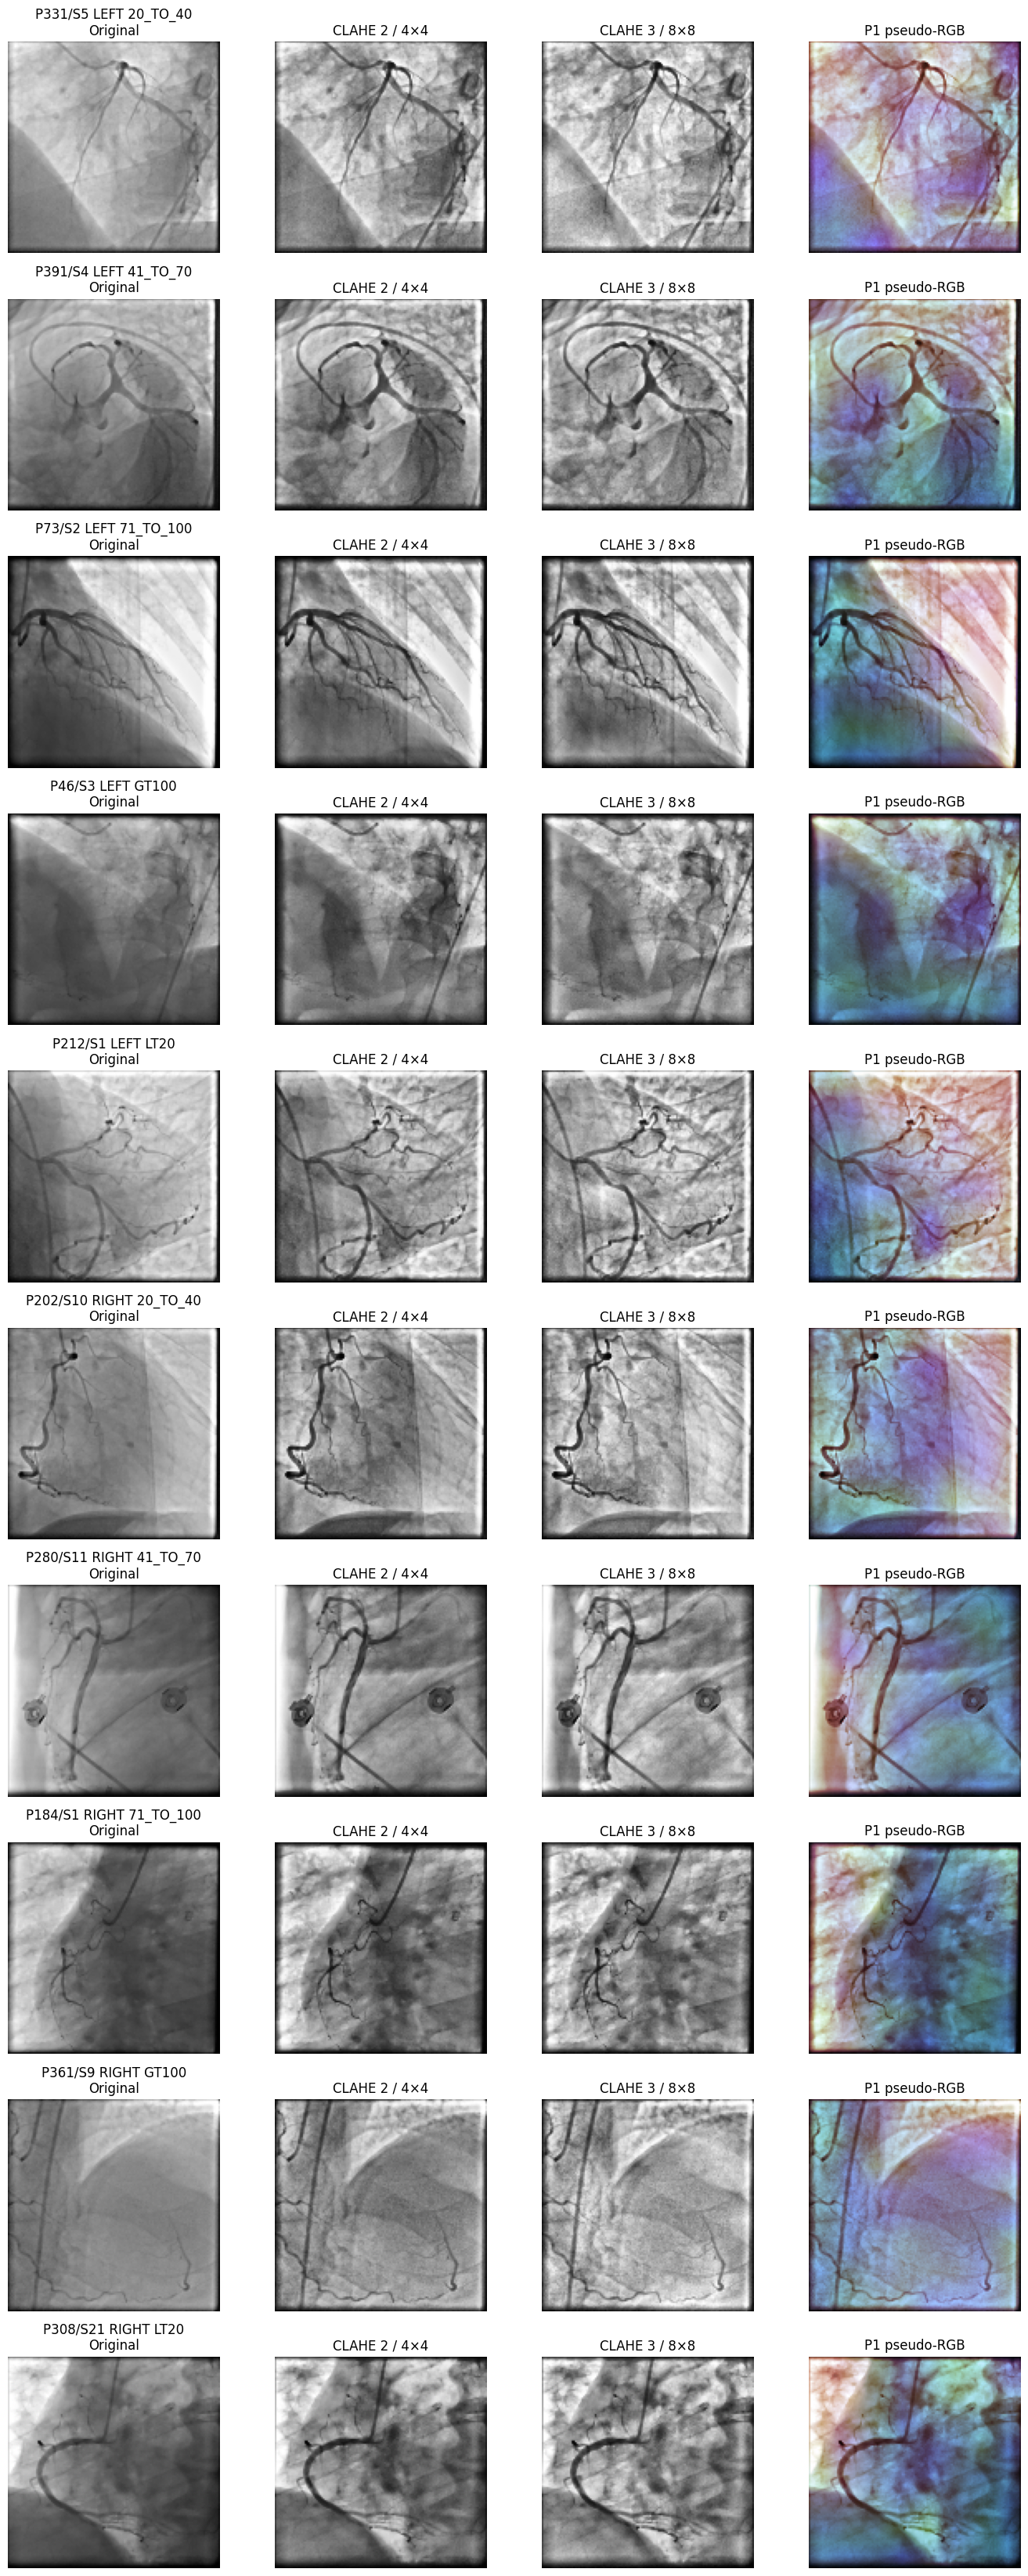

저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/08_image_preprocessing_samples.png


In [48]:
#@title 시각 검증

import matplotlib.pyplot as plt

visual_sample_df = (
    preprocessing_sample_df.loc[
        preprocessing_sample_df["sample_position"]
        == "MIDDLE"
    ]
    .sort_values(
        ["view", "length_group"]
    )
    .groupby(
        ["view", "length_group"],
        observed=True,
    )
    .head(1)
    .reset_index(drop=True)
)

n_rows = len(visual_sample_df)

fig, axes = plt.subplots(
    n_rows,
    4,
    figsize=(14, 3.3 * n_rows),
)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, row in enumerate(
    visual_sample_df.itertuples(index=False)
):
    p1 = preprocess_p1_keyframe(
        row.file_path
    )

    p2 = preprocess_p2_classifier(
        row.file_path
    )

    title_prefix = (
        f"P{row.patient_id}/S{row.series_id} "
        f"{row.view} {row.length_group}"
    )

    axes[row_index, 0].imshow(
        p1[..., 0],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 0].set_title(
        f"{title_prefix}\nOriginal"
    )

    axes[row_index, 1].imshow(
        p1[..., 1],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 1].set_title(
        "CLAHE 2 / 4×4"
    )

    axes[row_index, 2].imshow(
        p1[..., 2],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 2].set_title(
        "CLAHE 3 / 8×8"
    )

    # 실제 색상이 아니라 서로 다른 세 채널의 시각화
    axes[row_index, 3].imshow(
        np.clip(p1, 0, 1)
    )
    axes[row_index, 3].set_title(
        "P1 pseudo-RGB"
    )

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()

MONTAGE_PATH = (
    PREPROCESSING_DIR
    / "08_image_preprocessing_samples.png"
)

plt.savefig(
    MONTAGE_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("저장:", MONTAGE_PATH)

In [49]:
#@title 규격과 QC저장

preprocessing_spec = {
    "image_size": [128, 128],
    "source_mode": "uint8 grayscale",
    "resize_interpolation": "cv2.INTER_AREA",
    "operation_order": [
        "read grayscale",
        "resize 512x512 to 128x128",
        "apply CLAHE",
        "stack channels",
        "normalize to float32 [0,1]",
    ],
    "P0": {
        "description": "raw grayscale repeated to 3 channels",
    },
    "P1_keyframe": {
        "channel_0": "original",
        "channel_1": "CLAHE clipLimit=2, grid=4x4",
        "channel_2": "CLAHE clipLimit=3, grid=8x8",
    },
    "P2_classifier": {
        "description": (
            "CLAHE clipLimit=2, grid=4x4 "
            "repeated to 3 channels"
        ),
        "note": (
            "paper classifier section is ambiguous; "
            "this is the primary documented interpretation"
        ),
    },
    "normalization": "float32 / 255.0",
    "augmentation_applied": False,
    "opencv_version": cv2.__version__,
    "numpy_version": np.__version__,
}

SPEC_PATH = (
    PREPROCESSING_DIR
    / "06_image_preprocessing_spec.json"
)

with open(
    SPEC_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        preprocessing_spec,
        file,
        ensure_ascii=False,
        indent=2,
    )

image_preprocessing_qc_df.to_csv(
    PREPROCESSING_DIR
    / "07_image_preprocessing_qc.csv",
    index=False,
    encoding="utf-8-sig",
)

print("저장 완료:")
print(SPEC_PATH)
print(
    PREPROCESSING_DIR
    / "07_image_preprocessing_qc.csv"
)
print(MONTAGE_PATH)

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/06_image_preprocessing_spec.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/07_image_preprocessing_qc.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/08_image_preprocessing_samples.png


In [50]:
#@title 전체 이미지 QC


from tqdm.auto import tqdm
import pandas as pd
import numpy as np

FULL_QC_PATH = (
    PREPROCESSING_DIR
    / "09_full_image_preprocessing_qc.csv"
)

PREPROCESSING_VERSION = "P0_P1_P2_v1"

QC_KEY_COLUMNS = [
    "patient_id",
    "series_id",
    "frame_index",
]

# ---------------------------------------------------------
# 이전 진행 결과가 있으면 이어서 실행
# ---------------------------------------------------------
if FULL_QC_PATH.exists():
    existing_full_qc_df = pd.read_csv(
        FULL_QC_PATH
    )

    existing_versions = set(
        existing_full_qc_df[
            "preprocessing_version"
        ].dropna().astype(str)
    )

    if existing_versions != {PREPROCESSING_VERSION}:
        raise RuntimeError(
            "기존 QC 파일의 전처리 버전이 다릅니다. "
            f"기존={existing_versions}, "
            f"현재={PREPROCESSING_VERSION}"
        )

    processed_keys = set(
        existing_full_qc_df[
            QC_KEY_COLUMNS
        ].itertuples(
            index=False,
            name=None,
        )
    )

    print(
        "이전 처리 프레임:",
        len(processed_keys),
    )

else:
    processed_keys = set()
    print("새로운 전체 QC를 시작합니다.")

remaining_mask = [
    (
        int(row.patient_id),
        int(row.series_id),
        int(row.frame_index),
    )
    not in processed_keys
    for row in eligible_frame_manifest_df.itertuples(
        index=False
    )
]

remaining_frame_df = (
    eligible_frame_manifest_df.loc[
        remaining_mask
    ]
    .reset_index(drop=True)
)

print("남은 프레임:", len(remaining_frame_df))

새로운 전체 QC를 시작합니다.
남은 프레임: 119046


In [52]:
print("QC 파일 존재:", FULL_QC_PATH.exists())
print("처리 예정 프레임:", len(remaining_frame_df))

QC 파일 존재: False
처리 예정 프레임: 119046


In [53]:
#@title 전체 119,046장 전처리 QC 실행

BATCH_SIZE = 2000
batch_records = []

FULL_QC_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

for row in tqdm(
    remaining_frame_df.itertuples(index=False),
    total=len(remaining_frame_df),
    desc="전체 이미지 전처리 QC",
):
    record = {
        "preprocessing_version": PREPROCESSING_VERSION,
        "patient_id": int(row.patient_id),
        "series_id": int(row.series_id),
        "frame_index": int(row.frame_index),
        "view": row.view,
        "file_path": row.file_path,
        "status": "PASS",
        "error": "",
    }

    try:
        p1 = preprocess_p1_keyframe(
            row.file_path
        )

        original = p1[..., 0]
        enhanced_1 = p1[..., 1]
        enhanced_2 = p1[..., 2]

        record.update({
            "output_valid": output_is_valid(p1),

            "original_mean": float(original.mean()),
            "original_std": float(original.std()),

            "clahe1_mean": float(enhanced_1.mean()),
            "clahe1_std": float(enhanced_1.std()),

            "clahe2_mean": float(enhanced_2.mean()),
            "clahe2_std": float(enhanced_2.std()),

            "original_clahe1_mae": float(
                np.mean(
                    np.abs(
                        original - enhanced_1
                    )
                )
            ),

            "original_clahe2_mae": float(
                np.mean(
                    np.abs(
                        original - enhanced_2
                    )
                )
            ),

            "original_zero_rate": float(
                np.mean(original == 0.0)
            ),
            "original_one_rate": float(
                np.mean(original == 1.0)
            ),

            "clahe1_zero_rate": float(
                np.mean(enhanced_1 == 0.0)
            ),
            "clahe1_one_rate": float(
                np.mean(enhanced_1 == 1.0)
            ),

            "clahe2_zero_rate": float(
                np.mean(enhanced_2 == 0.0)
            ),
            "clahe2_one_rate": float(
                np.mean(enhanced_2 == 1.0)
            ),

            "low_contrast_flag": bool(
                original.std() < 0.01
            ),
        })

        if not record["output_valid"]:
            record["status"] = "INVALID_OUTPUT"

    except Exception as error:
        record["status"] = "ERROR"
        record["error"] = repr(error)

    batch_records.append(record)

    if len(batch_records) >= BATCH_SIZE:
        batch_df = pd.DataFrame(batch_records)

        write_header = not FULL_QC_PATH.exists()

        batch_df.to_csv(
            FULL_QC_PATH,
            mode="a",
            header=write_header,
            index=False,
            encoding="utf-8",
        )

        batch_records = []

# 마지막 잔여 결과 저장
if batch_records:
    batch_df = pd.DataFrame(batch_records)

    write_header = not FULL_QC_PATH.exists()

    batch_df.to_csv(
        FULL_QC_PATH,
        mode="a",
        header=write_header,
        index=False,
        encoding="utf-8",
    )

assert FULL_QC_PATH.exists(), (
    "전체 QC 결과 파일이 생성되지 않았습니다."
)

print("\n✅ 전체 이미지 QC 계산 완료")
print("저장:", FULL_QC_PATH)
print(
    "저장된 파일 크기:",
    round(
        FULL_QC_PATH.stat().st_size
        / (1024 ** 2),
        2,
    ),
    "MB",
)

전체 이미지 전처리 QC:   0%|          | 0/119046 [00:00<?, ?it/s]


✅ 전체 이미지 QC 계산 완료
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/09_full_image_preprocessing_qc.csv
저장된 파일 크기: 35.91 MB


In [54]:
#@title 전체 결과 검증
full_image_qc_df = pd.read_csv(
    FULL_QC_PATH
)

for column in QC_KEY_COLUMNS:
    full_image_qc_df[column] = pd.to_numeric(
        full_image_qc_df[column],
        errors="raise",
    ).astype(int)

duplicate_qc_keys = (
    full_image_qc_df.duplicated(
        QC_KEY_COLUMNS
    ).sum()
)

status_counts = (
    full_image_qc_df["status"]
    .value_counts(dropna=False)
)

error_count = (
    full_image_qc_df["status"]
    .eq("ERROR")
    .sum()
)

invalid_output_count = (
    full_image_qc_df["status"]
    .eq("INVALID_OUTPUT")
    .sum()
)

low_contrast_count = (
    full_image_qc_df[
        "low_contrast_flag"
    ].fillna(False).sum()
)

clahe1_no_change_count = (
    full_image_qc_df[
        "original_clahe1_mae"
    ].fillna(0).eq(0).sum()
)

clahe2_no_change_count = (
    full_image_qc_df[
        "original_clahe2_mae"
    ].fillna(0).eq(0).sum()
)

print("전체 QC 행:", len(full_image_qc_df))
print("중복 frame key:", duplicate_qc_keys)
print("\n상태 분포")
display(status_counts.rename("frame_count").to_frame())

print("읽기/처리 오류:", error_count)
print("비정상 출력:", invalid_output_count)
print("저대비 프레임:", low_contrast_count)
print(
    "CLAHE1 변화 없음:",
    clahe1_no_change_count,
)
print(
    "CLAHE2 변화 없음:",
    clahe2_no_change_count,
)

assert len(full_image_qc_df) == 119046
assert duplicate_qc_keys == 0
assert error_count == 0
assert invalid_output_count == 0

print("\n✅ 119,046개 전체 이미지 전처리 Gate 통과")

전체 QC 행: 119046
중복 frame key: 0

상태 분포


,frame_count
status,
PASS,119046


읽기/처리 오류: 0
비정상 출력: 0
저대비 프레임: 0
CLAHE1 변화 없음: 0
CLAHE2 변화 없음: 0

✅ 119,046개 전체 이미지 전처리 Gate 통과


In [55]:
#@title 분포 요약과 이상치 후보
metric_columns = [
    "original_mean",
    "original_std",
    "clahe1_mean",
    "clahe1_std",
    "clahe2_mean",
    "clahe2_std",
    "original_clahe1_mae",
    "original_clahe2_mae",
    "original_zero_rate",
    "original_one_rate",
    "clahe1_zero_rate",
    "clahe1_one_rate",
    "clahe2_zero_rate",
    "clahe2_one_rate",
]

full_qc_distribution_df = (
    full_image_qc_df[
        metric_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.5,
            0.95,
            0.99,
        ]
    )
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(full_qc_distribution_df)

print("\n=== 원본 contrast가 가장 낮은 프레임 ===")

lowest_contrast_df = (
    full_image_qc_df
    .sort_values(
        "original_std",
        ascending=True,
    )
    .head(15)
)

display(
    lowest_contrast_df[
        [
            "patient_id",
            "series_id",
            "frame_index",
            "view",
            "original_mean",
            "original_std",
            "file_path",
        ]
    ]
)

print("\n=== CLAHE2 흰색 포화율이 높은 프레임 ===")

highest_saturation_df = (
    full_image_qc_df
    .sort_values(
        "clahe2_one_rate",
        ascending=False,
    )
    .head(15)
)

display(
    highest_saturation_df[
        [
            "patient_id",
            "series_id",
            "frame_index",
            "view",
            "clahe2_one_rate",
            "original_clahe2_mae",
            "file_path",
        ]
    ]
)

FULL_SUMMARY_PATH = (
    PREPROCESSING_DIR
    / "10_full_image_preprocessing_summary.csv"
)

full_qc_distribution_df.to_csv(
    FULL_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", FULL_SUMMARY_PATH)

,metric,count,mean,std,min,1%,5%,50%,95%,99%,max
0,original_mean,119046.0,0.453407,0.056710,0.088456,0.335674,0.384032,0.442078,0.564601,0.620958,0.716357
1,original_std,119046.0,0.178137,0.041390,0.045049,0.085021,0.107477,0.177211,0.248282,0.277039,0.358015
2,clahe1_mean,119046.0,0.493381,0.038078,0.107570,0.377538,0.447783,0.489746,0.557779,0.586503,0.649358
3,clahe1_std,119046.0,0.189688,0.026558,0.089759,0.123406,0.139267,0.191120,0.230113,0.262070,0.331149
4,clahe2_mean,119046.0,0.558777,0.045862,0.119508,0.431246,0.502551,0.552610,0.632531,0.662118,0.732228
5,clahe2_std,119046.0,0.195900,0.023401,0.121278,0.143629,0.157682,0.195677,0.233193,0.278775,0.353779
6,original_clahe1_mae,119046.0,0.080147,0.012210,0.018228,0.052601,0.060702,0.080415,0.099296,0.106674,0.125388
7,original_clahe2_mae,119046.0,0.137133,0.016229,0.032996,0.094077,0.109583,0.138352,0.161198,0.169470,0.188927
8,original_zero_rate,119046.0,0.015578,0.046006,0.000000,0.000000,0.000000,0.005554,0.047546,0.210693,0.780640
9,original_one_rate,119046.0,0.003347,0.006712,0.000000,0.000000,0.000000,0.000366,0.017151,0.031860,0.066772



=== 원본 contrast가 가장 낮은 프레임 ===


,patient_id,series_id,frame_index,view,original_mean,original_std,file_path
31948,107,1,0,RIGHT,0.295991,0.045049,/content/AngioCAD/AngioCAD_Dataset/107/1/frame...
39878,142,2,0,RIGHT,0.427786,0.058496,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39885,142,2,7,RIGHT,0.446500,0.060505,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39884,142,2,6,RIGHT,0.448515,0.060747,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39891,142,2,13,RIGHT,0.446929,0.060764,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39892,142,2,14,RIGHT,0.447671,0.060813,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39893,142,2,15,RIGHT,0.448001,0.060930,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39910,142,2,32,RIGHT,0.451056,0.061070,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39886,142,2,8,RIGHT,0.446093,0.061229,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39890,142,2,12,RIGHT,0.447208,0.061371,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...



=== CLAHE2 흰색 포화율이 높은 프레임 ===


,patient_id,series_id,frame_index,view,clahe2_one_rate,original_clahe2_mae,file_path
51809,180,5,19,LEFT,0.066772,0.114919,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51817,180,5,27,LEFT,0.065247,0.120867,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51808,180,5,18,LEFT,0.065125,0.115270,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51816,180,5,26,LEFT,0.065063,0.122825,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51807,180,5,17,LEFT,0.065002,0.117075,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51810,180,5,20,LEFT,0.064941,0.122200,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51822,180,5,32,LEFT,0.064514,0.120837,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51823,180,5,33,LEFT,0.064453,0.122703,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51811,180,5,21,LEFT,0.064209,0.118754,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51812,180,5,22,LEFT,0.064148,0.117610,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/10_full_image_preprocessing_summary.csv


In [1]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

AUDIT_DIR = PROJECT_DIR / "audit_results"

PREPROCESSING_DIR = (
    PROJECT_DIR / "preprocessing_results"
)

FULL_QC_PATH = (
    PREPROCESSING_DIR
    / "09_full_image_preprocessing_qc.csv"
)

assert FULL_QC_PATH.exists(), (
    f"전체 QC 파일이 없습니다: {FULL_QC_PATH}"
)

full_image_qc_df = pd.read_csv(
    FULL_QC_PATH
)

print("복구된 전체 QC 행:", len(full_image_qc_df))
print(
    full_image_qc_df["status"]
    .value_counts(dropna=False)
)

assert len(full_image_qc_df) == 119046
assert full_image_qc_df["status"].eq("PASS").all()

print("✅ 전체 이미지 QC 결과 복구 완료")
print("✅ 이미지 재처리는 필요하지 않습니다.")

Mounted at /content/drive
복구된 전체 QC 행: 119046
status
PASS    119046
Name: count, dtype: int64
✅ 전체 이미지 QC 결과 복구 완료
✅ 이미지 재처리는 필요하지 않습니다.


In [2]:
#@title 전체 통계 요약

metric_columns = [
    "original_mean",
    "original_std",
    "clahe1_mean",
    "clahe1_std",
    "clahe2_mean",
    "clahe2_std",
    "original_clahe1_mae",
    "original_clahe2_mae",
    "original_zero_rate",
    "original_one_rate",
    "clahe1_zero_rate",
    "clahe1_one_rate",
    "clahe2_zero_rate",
    "clahe2_one_rate",
]

full_qc_distribution_df = (
    full_image_qc_df[
        metric_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
        ]
    )
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(full_qc_distribution_df)

print("\n=== 원본 contrast가 낮은 프레임 ===")

lowest_contrast_df = (
    full_image_qc_df
    .sort_values(
        "original_std",
        ascending=True,
    )
    .head(15)
)

display(
    lowest_contrast_df[
        [
            "patient_id",
            "series_id",
            "frame_index",
            "view",
            "original_mean",
            "original_std",
            "file_path",
        ]
    ]
)

print("\n=== CLAHE2 흰색 포화율 상위 프레임 ===")

highest_saturation_df = (
    full_image_qc_df
    .sort_values(
        "clahe2_one_rate",
        ascending=False,
    )
    .head(15)
)

display(
    highest_saturation_df[
        [
            "patient_id",
            "series_id",
            "frame_index",
            "view",
            "clahe2_one_rate",
            "original_clahe2_mae",
            "file_path",
        ]
    ]
)

FULL_SUMMARY_PATH = (
    PREPROCESSING_DIR
    / "10_full_image_preprocessing_summary.csv"
)

full_qc_distribution_df.to_csv(
    FULL_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("저장:", FULL_SUMMARY_PATH)

,metric,count,mean,std,min,1%,5%,50%,95%,99%,max
0,original_mean,119046.0,0.453407,0.056710,0.088456,0.335674,0.384032,0.442078,0.564601,0.620958,0.716357
1,original_std,119046.0,0.178137,0.041390,0.045049,0.085021,0.107477,0.177211,0.248282,0.277039,0.358015
2,clahe1_mean,119046.0,0.493381,0.038078,0.107570,0.377538,0.447783,0.489746,0.557779,0.586503,0.649358
3,clahe1_std,119046.0,0.189688,0.026558,0.089759,0.123406,0.139267,0.191120,0.230113,0.262070,0.331149
4,clahe2_mean,119046.0,0.558777,0.045862,0.119508,0.431246,0.502551,0.552610,0.632531,0.662118,0.732228
5,clahe2_std,119046.0,0.195900,0.023401,0.121278,0.143629,0.157682,0.195677,0.233193,0.278775,0.353779
6,original_clahe1_mae,119046.0,0.080147,0.012210,0.018228,0.052601,0.060702,0.080415,0.099296,0.106674,0.125388
7,original_clahe2_mae,119046.0,0.137133,0.016229,0.032996,0.094077,0.109583,0.138352,0.161198,0.169470,0.188927
8,original_zero_rate,119046.0,0.015578,0.046006,0.000000,0.000000,0.000000,0.005554,0.047546,0.210693,0.780640
9,original_one_rate,119046.0,0.003347,0.006712,0.000000,0.000000,0.000000,0.000366,0.017151,0.031860,0.066772



=== 원본 contrast가 낮은 프레임 ===


,patient_id,series_id,frame_index,view,original_mean,original_std,file_path
31948,107,1,0,RIGHT,0.295991,0.045049,/content/AngioCAD/AngioCAD_Dataset/107/1/frame...
39878,142,2,0,RIGHT,0.427786,0.058496,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39885,142,2,7,RIGHT,0.446500,0.060505,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39884,142,2,6,RIGHT,0.448515,0.060747,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39891,142,2,13,RIGHT,0.446929,0.060764,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39892,142,2,14,RIGHT,0.447671,0.060813,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39893,142,2,15,RIGHT,0.448001,0.060930,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39910,142,2,32,RIGHT,0.451056,0.061070,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39886,142,2,8,RIGHT,0.446093,0.061229,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...
39890,142,2,12,RIGHT,0.447208,0.061371,/content/AngioCAD/AngioCAD_Dataset/142/2/frame...



=== CLAHE2 흰색 포화율 상위 프레임 ===


,patient_id,series_id,frame_index,view,clahe2_one_rate,original_clahe2_mae,file_path
51809,180,5,19,LEFT,0.066772,0.114919,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51817,180,5,27,LEFT,0.065247,0.120867,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51808,180,5,18,LEFT,0.065125,0.115270,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51816,180,5,26,LEFT,0.065063,0.122825,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51807,180,5,17,LEFT,0.065002,0.117075,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51810,180,5,20,LEFT,0.064941,0.122200,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51822,180,5,32,LEFT,0.064514,0.120837,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51823,180,5,33,LEFT,0.064453,0.122703,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51811,180,5,21,LEFT,0.064209,0.118754,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...
51812,180,5,22,LEFT,0.064148,0.117610,/content/AngioCAD/AngioCAD_Dataset/180/5/frame...


저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/10_full_image_preprocessing_summary.csv


In [3]:
#@title 전처리 완료 판정 저장

completion_gate_df = pd.DataFrame([
    {
        "check": "eligible_frame_manifest",
        "observed": 119046,
        "expected": 119046,
        "status": "PASS",
    },
    {
        "check": "duplicate_gate",
        "observed": 0,
        "expected": 0,
        "status": "PASS",
    },
    {
        "check": "source_image_gate",
        "observed": 2680,
        "expected": 2680,
        "status": "PASS",
    },
    {
        "check": "sample_preprocessing_qc",
        "observed": 60,
        "expected": 60,
        "status": "PASS",
    },
    {
        "check": "full_preprocessing_qc",
        "observed": len(full_image_qc_df),
        "expected": 119046,
        "status": (
            "PASS"
            if (
                len(full_image_qc_df) == 119046
                and full_image_qc_df[
                    "status"
                ].eq("PASS").all()
            )
            else "FAIL"
        ),
    },
])

display(completion_gate_df)

assert completion_gate_df[
    "status"
].eq("PASS").all()

COMPLETION_PATH = (
    PREPROCESSING_DIR
    / "11_preprocessing_completion_gate.csv"
)

completion_gate_df.to_csv(
    COMPLETION_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ 02 전처리 단계 최종 완료")
print("✅ 03 환자 단위 데이터 분할로 이동 가능")
print("저장:", COMPLETION_PATH)

,check,observed,expected,status
0,eligible_frame_manifest,119046,119046,PASS
1,duplicate_gate,0,0,PASS
2,source_image_gate,2680,2680,PASS
3,sample_preprocessing_qc,60,60,PASS
4,full_preprocessing_qc,119046,119046,PASS



✅ 02 전처리 단계 최종 완료
✅ 03 환자 단위 데이터 분할로 이동 가능
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/preprocessing_results/11_preprocessing_completion_gate.csv
